# **Supervised Learning**

### **Definition:**

Supervised learning is a type of machine learning in which a model is trained on a labeled dataset, meaning each input is paired with a known output. The algorithm learns the relationship between the input features and the target variable so that it can accurately predict outcomes for new, unseen data.

### **Examples:**

*1. Classification*

- Predict if an email is spam or not spam

- Predict if a passenger survived in the Titanic dataset

*2. Regression* 

- House price 
    
- Salary prediction based on experience

*3. Decision Tree*

*4. Random Forest*

*3. Support Vector Machine*

### **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, accuracy_score, classification_report
from sklearn.datasets import load_iris
from sklearn.svm import SVC

## **Part-1: Regression(Simple Linear Regression)**

### **Load & Explore Dataset**

In [3]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [4]:
df.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [5]:
print("Missing Values: ")
df.isna().sum()

Missing Values: 


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### **Exploratory Data Analtsis (EDA)**

**Correlation Heatmap**

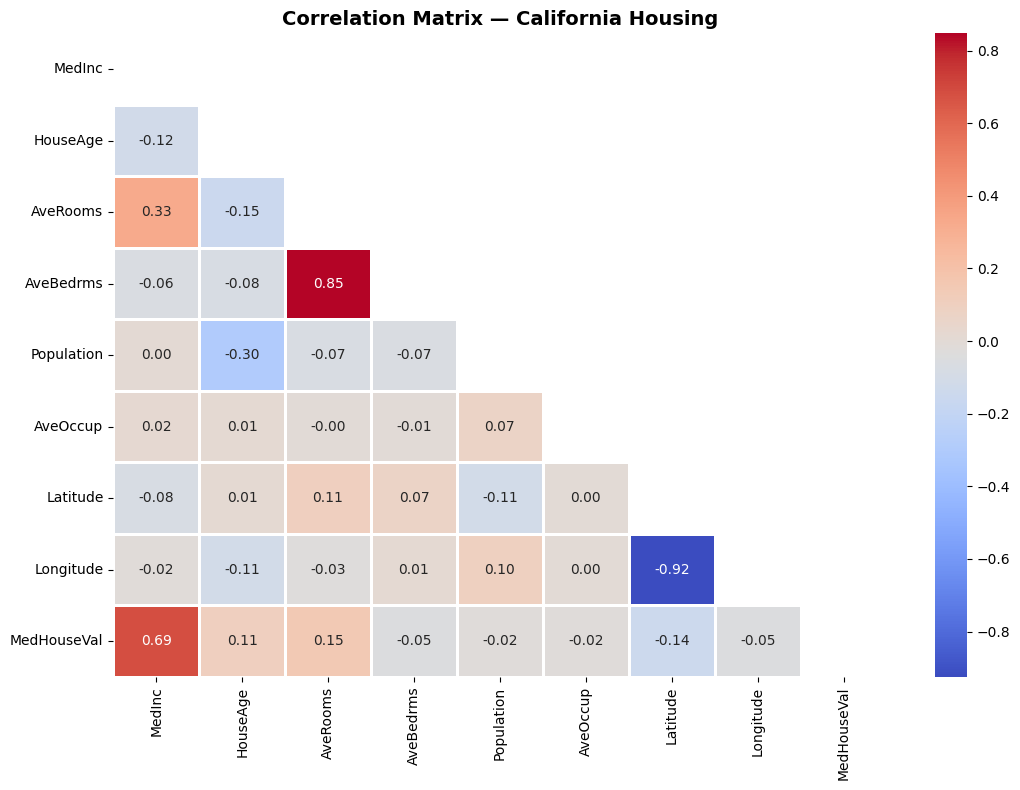

In [6]:
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)
plt.title('Correlation Matrix — California Housing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: MedInc (Median Income) has the strongest correlation with house value.

**Distribution of target variable**

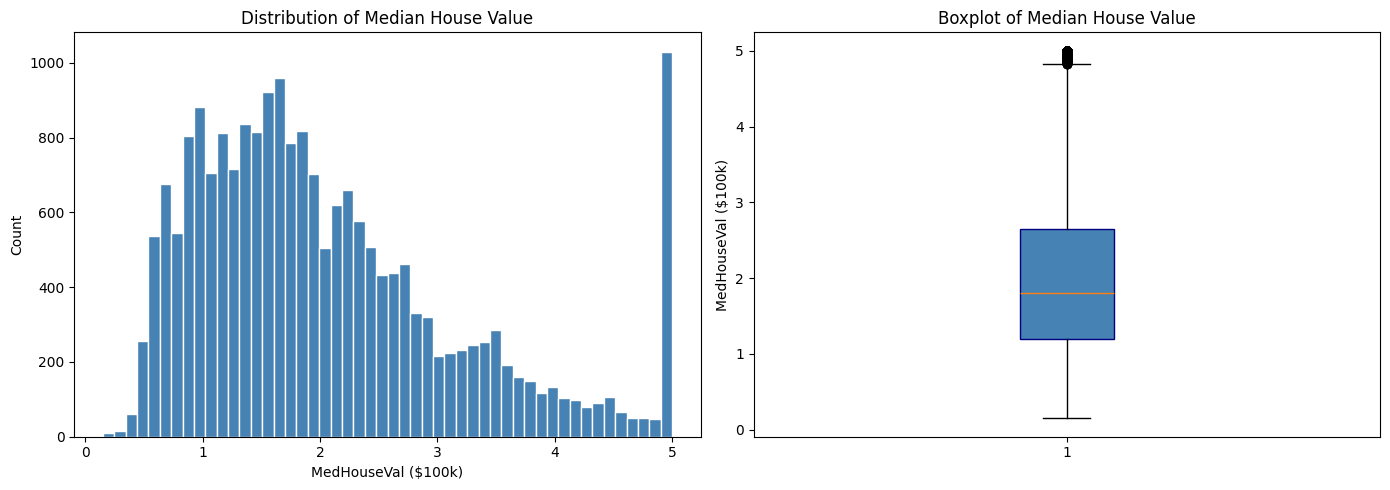

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('MedHouseVal ($100k)')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['MedHouseVal'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'))
axes[1].set_title('Boxplot of Median House Value')
axes[1].set_ylabel('MedHouseVal ($100k)')

plt.tight_layout()
plt.show()

**Scatter plots: Top 4 features vs Target**

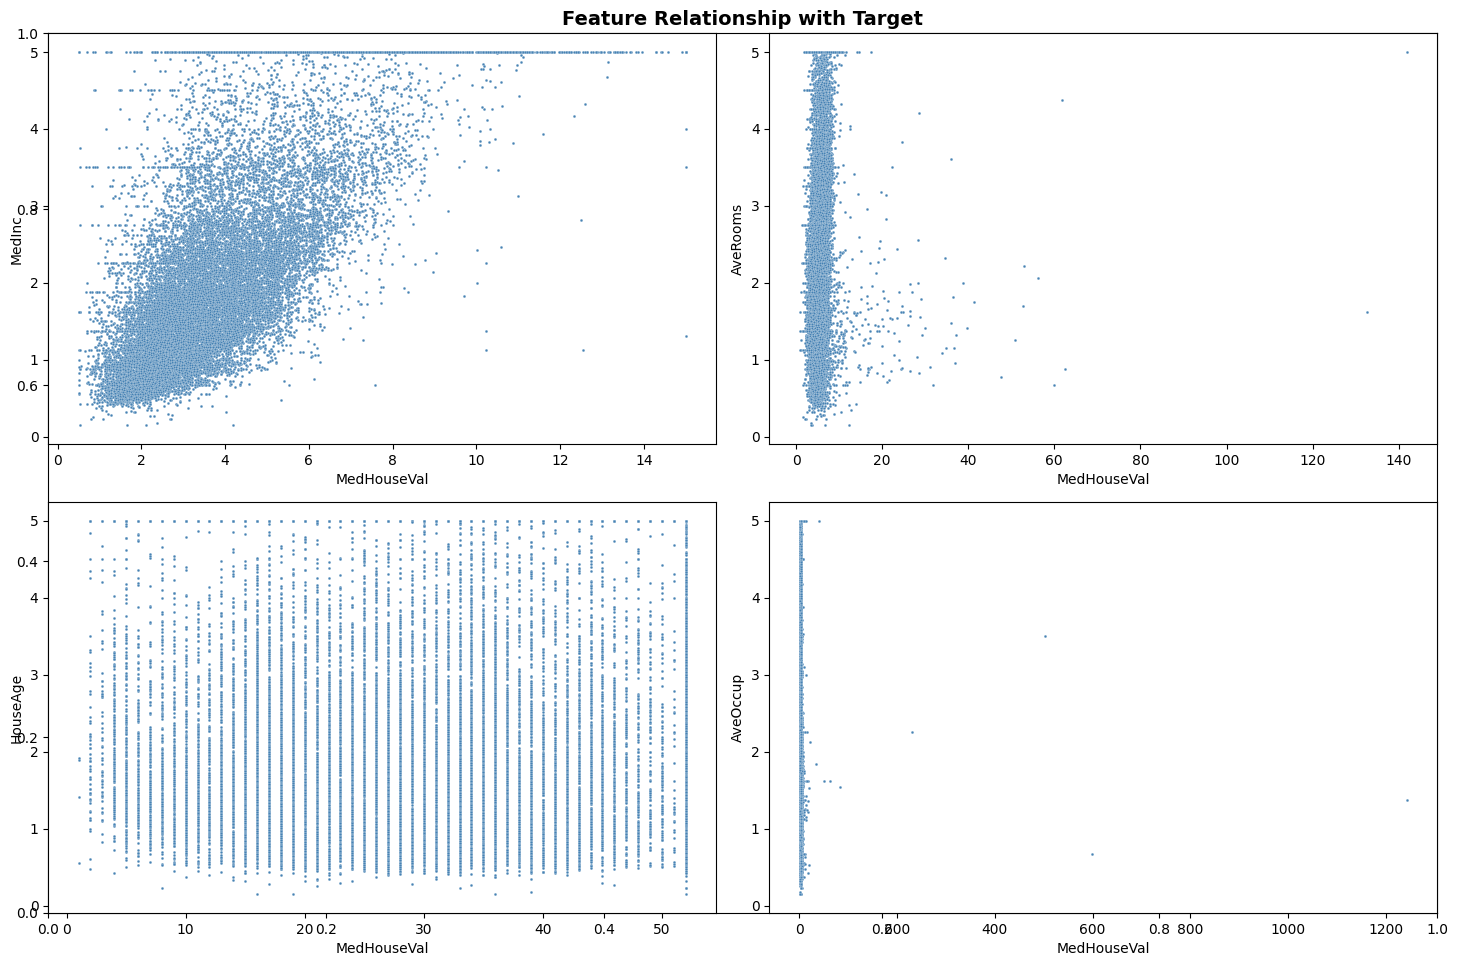

In [8]:
top_features = ['MedInc', 'AveRooms', 'HouseAge', 'AveOccup']
plt.figure(figsize=(15, 10))
plt.title("Feature Relationship with Target", fontsize=14, fontweight='bold')

for idx, col in enumerate(top_features):
    plt.subplot(2, 2, idx+1)
    sns.scatterplot(x=col, y="MedHouseVal", data=df, color='steelblue', s=4)
    plt.xlabel("MedHouseVal")
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### **Train Regression Model**

In [ ]:
X = df[["MedInc"]]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

y_pred_reg = reg_model.predict(X_test)

print('=== Simple Linear Regression ===')
print(f'  Coefficient  : {reg_model.coef_[0]:.4f}')
print(f'  Intercept    : {reg_model.intercept_:.4f}')
print(f'  Equation     : y = {reg_model.coef_[0]:.4f} * MedInc + {reg_model.intercept_:.4f}')

=== Simple Linear Regression ===
  Coefficient  : 0.4193
  Intercept    : 0.4446
  Equation     : y = 0.4193 * MedInc + 0.4446


### **Evaluate Regression**

In [10]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred_reg))
print("R2 Score:", r2_score(y_test, y_pred_reg))

MSE: 0.7091157771765548
R2 Score: 0.45885918903846656


### **Regression Plot**

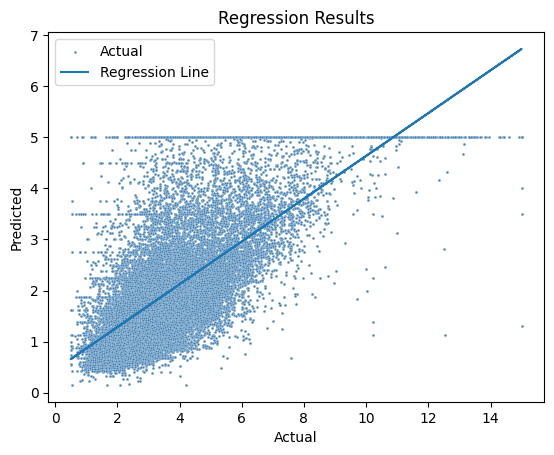

In [11]:
sns.scatterplot(x="MedInc", y="MedHouseVal", data=df, color='steelblue', s=4, label="Actual")
plt.plot(X_test, y_pred_reg, label="Regression Line")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Regression Results")
plt.legend()
plt.show()

## **Part-2: Classification(SVM)**

### **Load & Explore Dataset**

In [12]:
iris_data = load_iris()

iris_x = pd.DataFrame(data=iris_data.data, columns=iris_data.feature_names)
iris_y = iris_data.target

iris_df = iris_x.copy()
iris_df["target"] = iris_y

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [13]:
iris_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [14]:
iris_x.describe().round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


In [15]:
iris_df["target"].value_counts()

target
0    50
1    50
2    50
Name: count, dtype: int64

### **Exploratory Data Analtsis (EDA)**

**Pairplot**

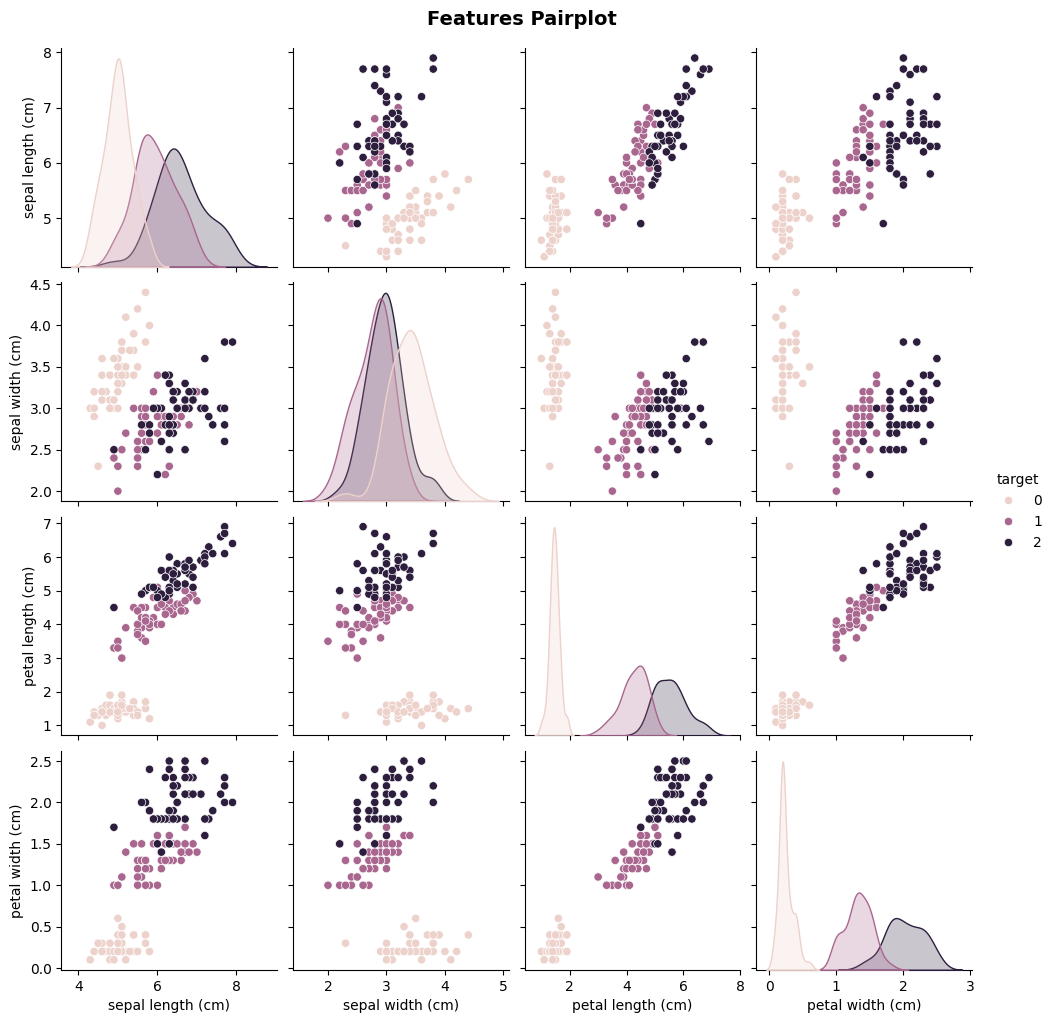

In [16]:
sns.pairplot(iris_df, hue="target")
plt.suptitle('Features Pairplot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

**Feature Distribution**

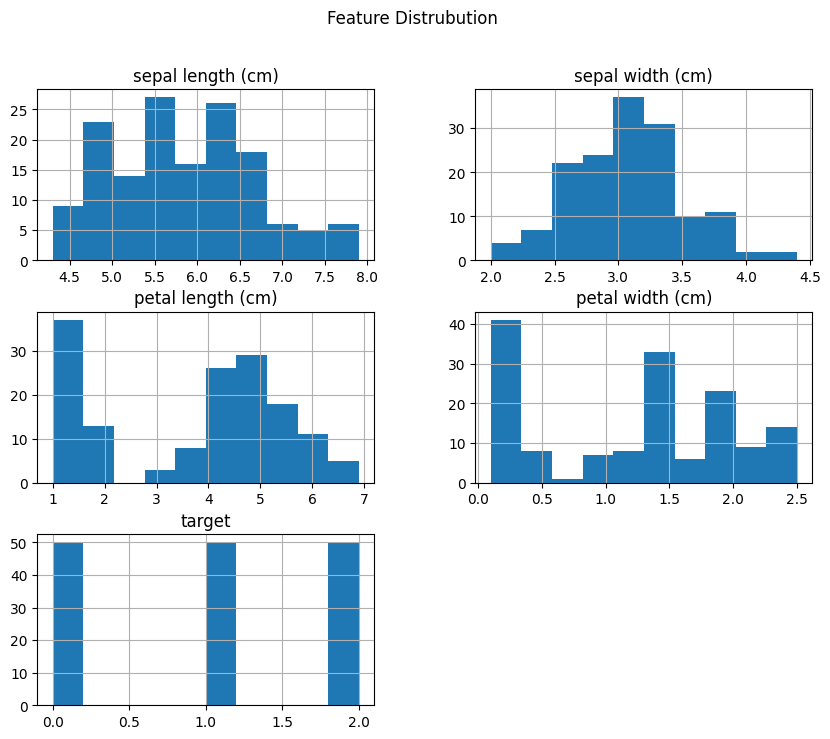

In [17]:
iris_df.hist(figsize=(10,8))
plt.suptitle("Feature Distrubution")
plt.show()

**Boxplot**

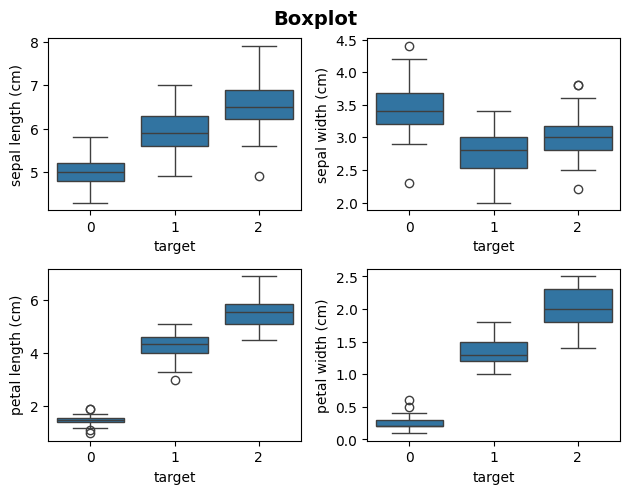

In [18]:
for i, col in enumerate(iris_df.columns[:-1]):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x="target", y=col, data=iris_df)
plt.tight_layout()
plt.suptitle("Boxplot", y=1.02, fontsize=14, fontweight="bold")
plt.show()

### **Train Classification Model**

In [19]:
# Split
iris_x_train, iris_x_test, iris_y_train, iris_y_test = train_test_split(
    iris_x, iris_y, test_size=0.2, random_state=42
)

# Scale X
scaler = StandardScaler()
iris_x_train = scaler.fit_transform(iris_x_train)
iris_x_test = scaler.transform(iris_x_test)

# Model
clf_model = SVC(max_iter=1000)
clf_model.fit(iris_x_train, iris_y_train)

y_pred_clf = clf_model.predict(iris_x_test)

### **Evaluate Classification**

In [20]:
print("Accuracy:", accuracy_score(iris_y_test, y_pred_clf))
print(classification_report(iris_y_test, y_pred_clf))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



### **Confusion Matrix**

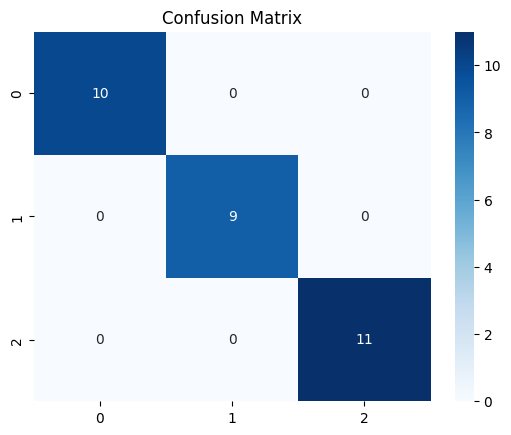

In [21]:
cm = confusion_matrix(iris_y_test, y_pred_clf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

### **<u>Conclusion:</u>**

* Supervised Learning uses labeled data to train models.
* Regression predicts continuous values, while classification predicts categories.